In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/food_delivery_time_estimation.csv")
df.head()

,order_id,distance_km,rider_speed,weather,delivery_time
0,ORD1000,7.80,30.94,Snowy,31.30
1,ORD1001,19.04,26.08,Stormy,64.03
2,ORD1002,14.77,19.29,Windy,49.46
3,ORD1003,12.17,34.41,Clear,18.61
4,ORD1004,3.54,30.54,Windy,14.76


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       500 non-null    object 
 1   distance_km    500 non-null    float64
 2   rider_speed    500 non-null    float64
 3   weather        500 non-null    object 
 4   delivery_time  500 non-null    float64
dtypes: float64(3), object(2)
memory usage: 19.7+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
distance_km,500.0,10.22188,5.824315,0.60,5.2075,10.510,15.2425,19.86
rider_speed,500.0,24.45854,8.564926,10.14,16.8750,24.155,31.7900,39.99
delivery_time,500.0,38.61370,22.027547,1.33,22.3275,34.975,51.4425,125.08


In [ ]:
df.isnull().sum()
df.head()

,order_id,distance_km,rider_speed,weather,delivery_time
0,ORD1000,7.80,30.94,Snowy,31.30
1,ORD1001,19.04,26.08,Stormy,64.03
2,ORD1002,14.77,19.29,Windy,49.46
3,ORD1003,12.17,34.41,Clear,18.61
4,ORD1004,3.54,30.54,Windy,14.76


In [ ]:
df.dtypes

,0
order_id,object
distance_km,float64
rider_speed,float64
weather,object
delivery_time,float64


Text(0.5, 1.0, 'Korelasyon Matrisi')

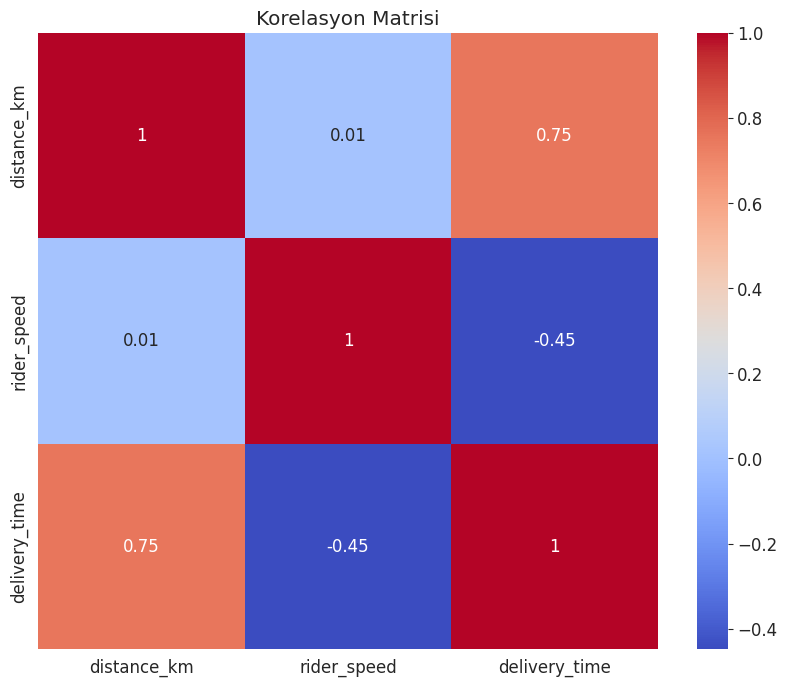

In [11]:
# Korelasyon matrisi
plt.figure(figsize=(10, 8))
df_numeric = df.select_dtypes(include=[np.number])
corr = df_numeric.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Korelasyon Matrisi')

In [18]:
target = 'delivery_time'
corr_with_target = corr[target].sort_values(ascending=False)
print('Teslimat Süresiyle ilgili korelasyonlar')
print(corr_with_target,'\n\n')
print("En iyi korelasyonun kendisiyle olduğunu doğrulayalım: ")
print(corr_with_target[0])


Teslimat Süresiyle ilgili korelasyonlar
delivery_time    1.000000
distance_km      0.753789
rider_speed     -0.447951
Name: delivery_time, dtype: float64 


En iyi korelasyonun kendisiyle olduğunu doğrulayalım: 
1.0


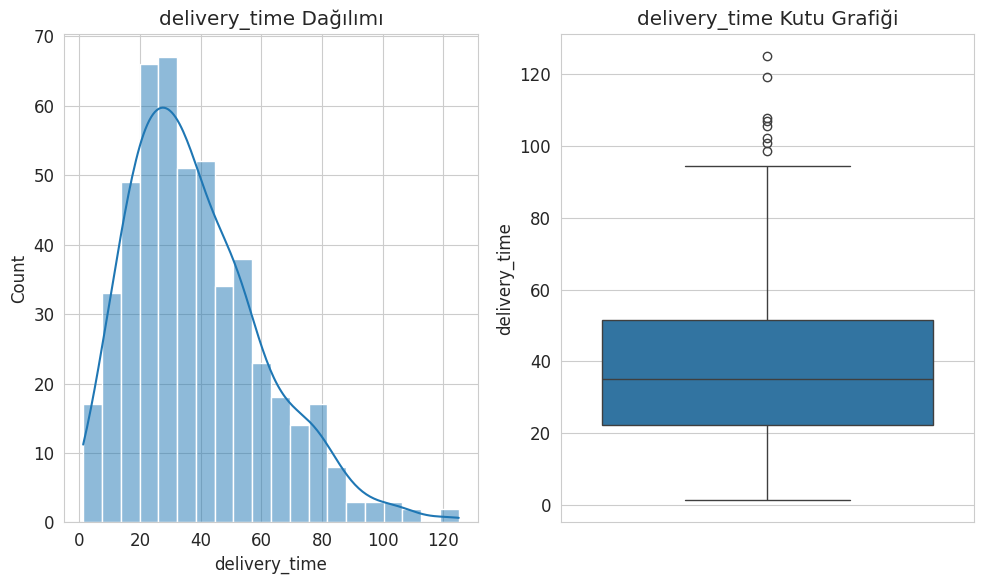

In [24]:
#Teslimat süresi dağılımı
plt.subplot(1, 2, 1)
sns.histplot(df[target], bins=20, kde=True)
plt.title(f'{target} Dağılımı')


plt.subplot(1, 2, 2)
sns.boxplot(y=df[target])
plt.title(f'{target} Kutu Grafiği')
plt.tight_layout()
plt.show()

In [28]:
X_simple = df['distance_km'].values
y_simple = df['delivery_time'].values
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

print(f'Eğitim seti boyutu: {X_train.shape[0]}')
print(f'Test seti boyutu: {X_test.shape[0]}')

Eğitim seti boyutu: 400
Test seti boyutu: 100


In [32]:
model_simple = LinearRegression()
model_simple.fit(X_train.reshape(-1, 1), y_train) #modeli oluştur ve eğit.

y_pred_train = model_simple.predict(X_train.reshape(-1, 1))
y_pred_test = model_simple.predict(X_test.reshape(-1, 1)) #tahmin yap

# Model parametreleri
beta_0 = model_simple.intercept_
beta_1 = model_simple.coef_[0]

print(f'Kesim Noktası (β₀): {beta_0:.4f}')
print(f'Eğim (β₁): {beta_1:.4f}')
print(f'Model Denklemi:')
print(f'Teslimat = {beta_0:.4f} + {beta_1:.4f} × Mesafe_km')

Kesim Noktası (β₀): 9.4739
Eğim (β₁): 2.8374
Model Denklemi:
Teslimat = 9.4739 + 2.8374 × Mesafe_km


In [35]:
results = pd.DataFrame({
    'Gerçek Teslimat Süresi': y_test,
    'Tahmin Edilen Teslimat Süresi': y_pred_test,
    'Fark': y_test - y_pred_test
})
print('Test Seti Tahminleri:')
print(results)

Test Seti Tahminleri:
    Gerçek Teslimat Süresi  Tahmin Edilen Teslimat Süresi       Fark
0                    36.63                      46.473830  -9.843830
1                    53.83                      56.007549  -2.177549
2                    30.25                      14.836636  15.413364
3                    24.49                      24.285233   0.204767
4                    98.52                      61.114899  37.405101
..                     ...                            ...        ...
95                    1.33                      13.389554 -12.059554
96                   75.22                      51.269064  23.950936
97                   22.88                      51.240690 -28.360690
98                   72.67                      49.963852  22.706148
99                   21.79                      21.050579   0.739421

[100 rows x 3 columns]


In [36]:
# Model performans metrikleri
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

metrics = pd.DataFrame({
    'Metrik': ['RMSE', 'MAE', 'R²'],
    'Eğitim': [f'{rmse_train:.3f}', f'{mae_train:.3f}', f'{r2_train:.3f}'],
    'Test': [f'{rmse_test:.3f}', f'{mae_test:.3f}', f'{r2_test:.3f}']
})
print('Model Performansı:')
print(metrics.to_string(index=False))

Model Performansı:
Metrik Eğitim   Test
  RMSE 14.759 13.203
   MAE 11.259  9.906
    R²  0.558  0.613


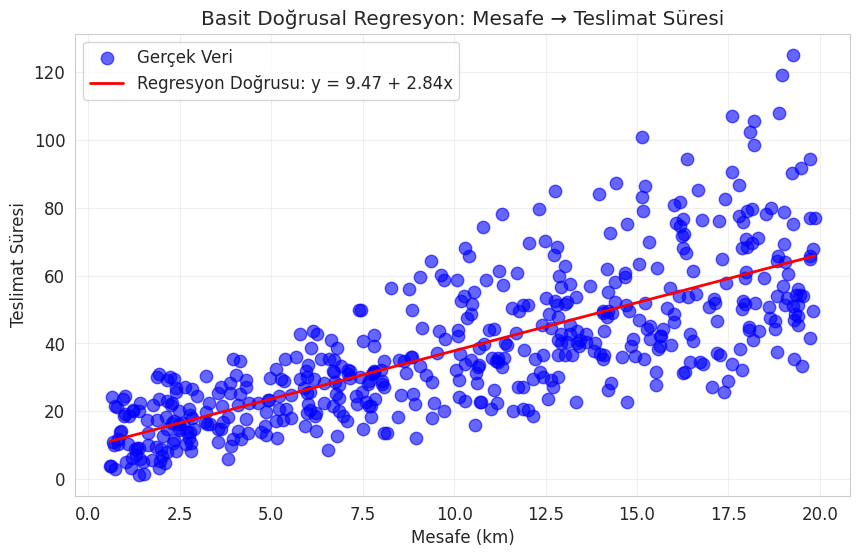

In [55]:
# Görselleştirme: Regresyon doğrusu
plt.figure(figsize=(10, 6))

# Tüm veri noktaları
plt.scatter(X_simple, y_simple, color='blue', alpha=0.6, label='Gerçek Veri', s=80)

# Regresyon doğrusu (x sıralı)
x_line = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)
y_line = model_simple.predict(x_line)
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Regresyon Doğrusu: y = {beta_0:.2f} + {beta_1:.2f}x')

plt.xlabel('Mesafe (km)')
plt.ylabel('Teslimat Süresi')
plt.title('Basit Doğrusal Regresyon: Mesafe → Teslimat Süresi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

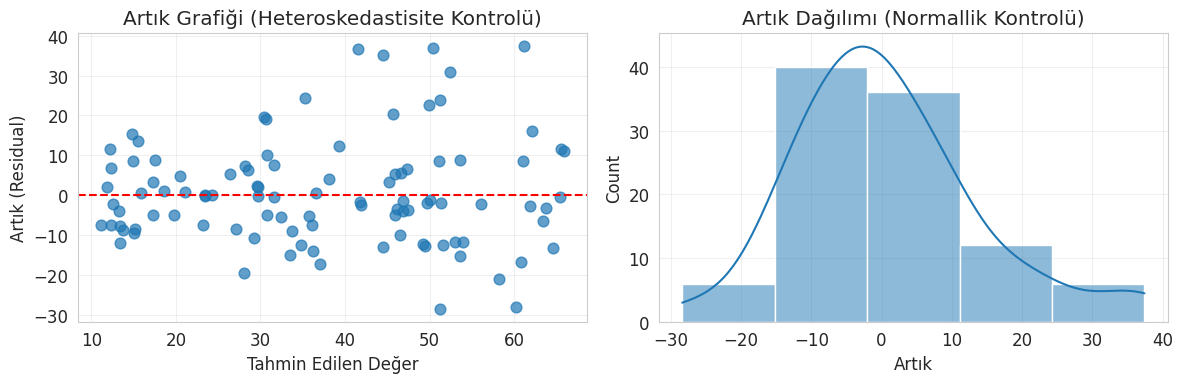

Artıkların ortalaması: 0.6803
Artıkların standart sapması: 13.1853


In [39]:
# Artık (Residual) analizi
residuals = y_test - y_pred_test

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_test, residuals, alpha=0.7, s=60)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Tahmin Edilen Değer')
plt.ylabel('Artık (Residual)')
plt.title('Artık Grafiği (Heteroskedastisite Kontrolü)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.histplot(residuals, bins=5, kde=True)
plt.xlabel('Artık')
plt.title('Artık Dağılımı (Normallik Kontrolü)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Artıkların ortalaması: {np.mean(residuals):.4f}')
print(f'Artıkların standart sapması: {np.std(residuals):.4f}')

In [41]:
# Teslimat Süresi ile en yüksek korelasyonlu özellikleri seçelim (korelasyon > 0.7 veya top 5)
target_corr = corr_with_target[1:8]  # order_id hariç en yüksek 7
print('Seçilen özellikler ve Teslimat Süresi ile korelasyonları:')
for feat, corr_val in target_corr.items():
    print(f'  {feat}: {corr_val:.4f}')

# Seçilen özellikler (yüksek korelasyonlu + mantıklı)
selected_features = ['distance_km', 'rider_speed']

available_features = [f for f in selected_features if f in df.columns]
print(f'Kullanılacak özellikler: {available_features}')

Seçilen özellikler ve Teslimat Süresi ile korelasyonları:
  distance_km: 0.7538
  rider_speed: -0.4480
Kullanılacak özellikler: ['distance_km', 'rider_speed']


In [43]:
X_multi = df[available_features].values
y_multi = df['delivery_time'].values

# Eğitim ve test setlerine ayır
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

print(f'Eğitim seti: {X_train_m.shape}')
print(f'Test seti: {X_test_m.shape}')

Eğitim seti: (400, 2)
Test seti: (100, 2)


In [45]:
# Çoklu doğrusal regresyon modelini oluştur ve eğit
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# Tahmin
y_pred_train_m = model_multi.predict(X_train_m)
y_pred_test_m = model_multi.predict(X_test_m)

# Model katsayıları
print('Kesim Noktası (Intercept):', model_multi.intercept_.round(4))
print('Katsayılar:')
for feat, coef in zip(available_features, model_multi.coef_):
    print(f'  {feat}: {coef:.4f}')

print(f'Model Denklemi:')
eq = f'Teslimat Süresi = {model_multi.intercept_:.2f}'
for feat, coef in zip(available_features, model_multi.coef_):
    eq += f' + ({coef:.2f} × {feat})'
print(eq)

Kesim Noktası (Intercept): 38.9753
Katsayılar:
  distance_km: 2.8510
  rider_speed: -1.2016
Model Denklemi:
Teslimat Süresi = 38.98 + (2.85 × distance_km) + (-1.20 × rider_speed)


In [46]:
# Model performansı
rmse_train_m = np.sqrt(mean_squared_error(y_train_m, y_pred_train_m))
rmse_test_m = np.sqrt(mean_squared_error(y_test_m, y_pred_test_m))
mae_train_m = mean_absolute_error(y_train_m, y_pred_train_m)
mae_test_m = mean_absolute_error(y_test_m, y_pred_test_m)
r2_train_m = r2_score(y_train_m, y_pred_train_m)
r2_test_m = r2_score(y_test_m, y_pred_test_m)

metrics_multi = pd.DataFrame({
    'Metrik': ['RMSE', 'MAE', 'R²'],
    'Eğitim': [f'{rmse_train_m:.3f}', f'{mae_train_m:.3f}', f'{r2_train_m:.3f}'],
    'Test': [f'{rmse_test_m:.3f}', f'{mae_test_m:.3f}', f'{r2_test_m:.3f}']
})
print('Çoklu Regresyon Model Performansı:')
print(metrics_multi.to_string(index=False))

Çoklu Regresyon Model Performansı:
Metrik Eğitim  Test
  RMSE 10.533 9.962
   MAE  8.352 8.078
    R²  0.775 0.779


In [47]:
# İki modeli karşılaştır (Test seti üzerinden)
comparison = pd.DataFrame({
    'Model': ['Basit Regresyon (xG)', 'Çoklu Regresyon'],
    'RMSE': [f'{rmse_test:.3f}', f'{rmse_test_m:.3f}'],
    'MAE': [f'{mae_test:.3f}', f'{mae_test_m:.3f}'],
    'R²': [f'{r2_test:.3f}', f'{r2_test_m:.3f}']
})
print('Model Karşılaştırması (Test Seti):')
print(comparison.to_string(index=False))

Model Karşılaştırması (Test Seti):
               Model   RMSE   MAE    R²
Basit Regresyon (xG) 13.203 9.906 0.613
     Çoklu Regresyon  9.962 8.078 0.779


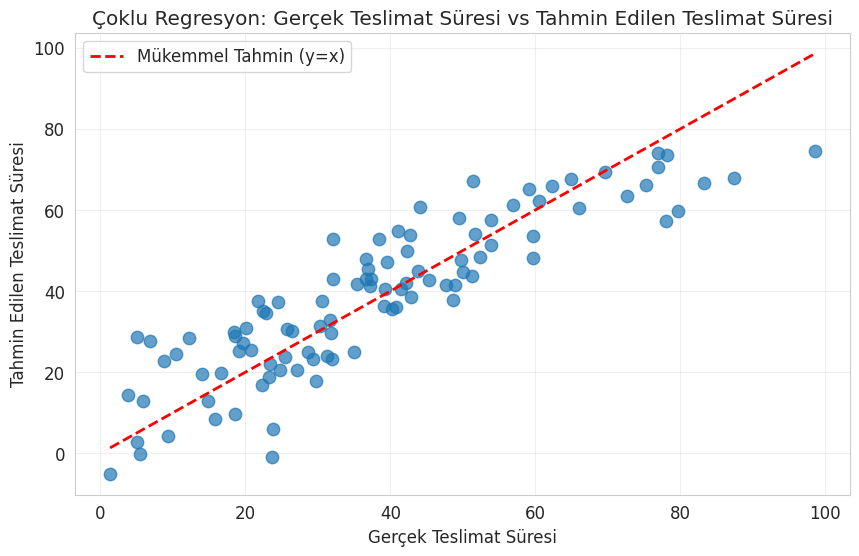

In [52]:
# Gerçek vs Tahmin karşılaştırması (Çoklu Regresyon)
plt.figure(figsize=(10, 6))
plt.scatter(y_test_m, y_pred_test_m, alpha=0.7, s=80)
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()],
         'r--', linewidth=2, label='Mükemmel Tahmin (y=x)')
plt.xlabel('Gerçek Teslimat Süresi')
plt.ylabel('Tahmin Edilen Teslimat Süresi')
plt.title('Çoklu Regresyon: Gerçek Teslimat Süresi vs Tahmin Edilen Teslimat Süresi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

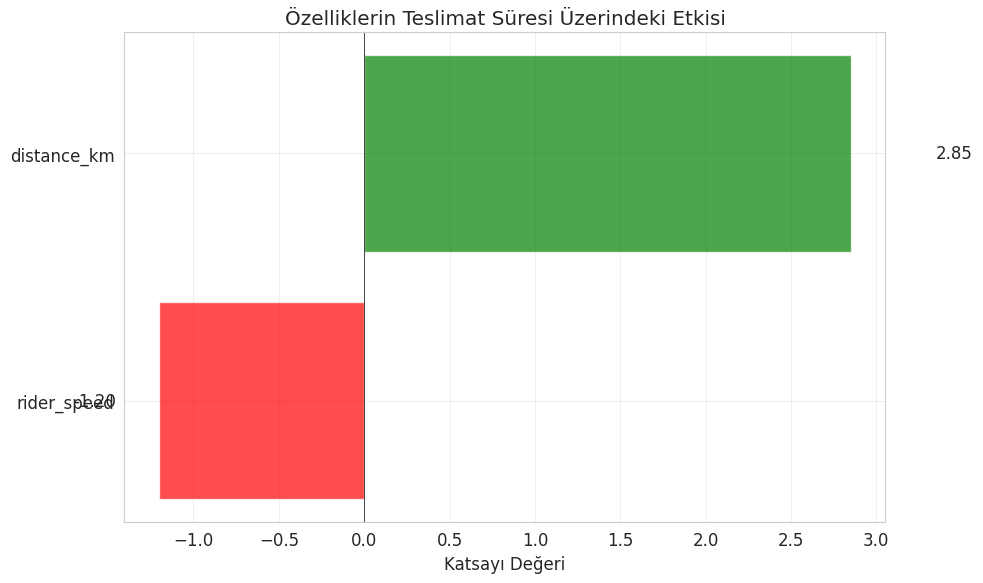

In [53]:
# Özellik önem sırası (katsayıların mutlak değerine göre)
feature_importance = pd.DataFrame({
    'Özellik': available_features,
    'Katsayı': model_multi.coef_,
    '|Katsayı|': np.abs(model_multi.coef_)
}).sort_values('|Katsayı|', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in feature_importance['Katsayı']]
bars = plt.barh(feature_importance['Özellik'], feature_importance['Katsayı'], color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Katsayı Değeri')
plt.title('Özelliklerin Teslimat Süresi Üzerindeki Etkisi')
for i, (v, feat) in enumerate(zip(feature_importance['Katsayı'], feature_importance['Özellik'])):
    plt.text(v + (0.5 if v > 0 else -0.5), i, f'{v:.2f}', va='center')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
# Tüm modelleri özetle
print('=' * 60)
print('REGRESYON ANALİZİ ÖZETİ')
print('=' * 60)
print(f'1. BASİT DOĞRUSAL REGRESYON')
print(f'   Hedef: Teslimat Süresi')
print(f'   Özellik: Mesafe_km')
print(f'   Denklem: Teslimat = {beta_0:.2f} + {beta_1:.2f} × Mesafe_km')
print(f'   Test R²: {r2_test:.3f}')
print(f'   Test RMSE: {rmse_test:.3f}')
print(f'   Test MAE: {mae_test:.3f}')

print(f'2. ÇOKLU DOĞRUSAL REGRESYON')
print(f'   Hedef: Teslimat Süresi')
print(f'   Özellikler: {available_features}')
print(f'   Test R²: {r2_test_m:.3f}')
print(f'   Test RMSE: {rmse_test_m:.3f}')
print(f'   Test MAE: {mae_test_m:.3f}')

print(f'3. MODEL KARŞILAŞTIRMASI')
better_model = 'Çoklu Regresyon' if r2_test_m > r2_test else 'Basit Regresyon'
print(f'   R² değerine göre daha iyi model: {better_model}')

REGRESYON ANALİZİ ÖZETİ
1. BASİT DOĞRUSAL REGRESYON
   Hedef: Teslimat Süresi
   Özellik: Mesafe_km
   Denklem: Teslimat = 9.47 + 2.84 × Mesafe_km
   Test R²: 0.613
   Test RMSE: 13.203
   Test MAE: 9.906
2. ÇOKLU DOĞRUSAL REGRESYON
   Hedef: Teslimat Süresi
   Özellikler: ['distance_km', 'rider_speed']
   Test R²: 0.779
   Test RMSE: 9.962
   Test MAE: 8.078
3. MODEL KARŞILAŞTIRMASI
   R² değerine göre daha iyi model: Çoklu Regresyon
